# Clinical Policy & Factuality Agent
**Course:** Agentic AI — Final Capstone Project  
**Architecture:** LangGraph · ChromaDB · SentenceTransformer · ChatGroq · MemorySaver  
**Goal:** RAG-powered hospital policy assistant with self-reflection (faithfulness eval) to prevent medical hallucinations.

## 1. Installation

In [1]:
# Install required packages
# Run this cell first (restart kernel after if needed)
try:
    import langgraph
    import chromadb
    import ragas
    print("✅ All dependencies are already installed and verified.")
except ImportError:
    print("Missing dependencies detected. Installing now...")
    %pip install -q langchain langchain-groq langgraph chromadb sentence-transformers streamlit ragas datasets pandas
    print("✅ Installation complete. Please restart the kernel if prompted.")

C:\Users\KIIT0001\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All dependencies are already installed and verified.


## 2. Environment Setup

In [ ]:
import os

# ── Set your API keys ──────────────────────────────────────────────────
# Option A: set in environment before launching Jupyter
# Option B: set here (do not commit keys to version control)

os.environ['GROQ_API_KEY'] = 'your_api_key_here'                  #<-- replace with your actual API key

print('Environment configured.')

Environment configured.


## 3. Import Agent & Initialize Resources

In [3]:
# Ensure agent.py is in the same directory as this notebook
from agent import (
    get_app, get_embedder, get_collection, get_llm,
    run_query, DOCUMENTS,
    drug_interaction_checker, get_current_datetime
)
import pandas as pd

# Initialize all heavy singletons
embedder   = get_embedder()
collection = get_collection()
llm        = get_llm()
app        = get_app()

print(f'ChromaDB seeded with {collection.count()} documents.')
print('Agent ready.')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5278.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ChromaDB seeded with 10 documents.
Agent ready.


## 4. Knowledge Base Verification

In [4]:
print('=== Knowledge Base Documents ===')
for i, doc in enumerate(DOCUMENTS, 1):
    word_count = len(doc['content'].split())
    print(f'{i:>2}. [{doc["id"]}] {doc["title"]:45s} ({word_count} words)')

=== Knowledge Base Documents ===
 1. [doc_001] Hand Hygiene Protocol                         (178 words)
 2. [doc_002] Medication Administration Policy              (162 words)
 3. [doc_003] Fall Prevention Protocol                      (164 words)
 4. [doc_004] Sepsis Management Bundle (Hour-1 Bundle)      (150 words)
 5. [doc_005] Blood Transfusion Policy                      (166 words)
 6. [doc_006] Pain Assessment and Management Policy         (160 words)
 7. [doc_007] Isolation Precautions Policy                  (145 words)
 8. [doc_008] Code Blue / Cardiac Arrest Protocol           (142 words)
 9. [doc_009] Patient Identification Policy                 (172 words)
10. [doc_010] Antibiotic Stewardship Policy                 (152 words)


## 5. Tool Verification

In [5]:
print('=== Drug Interaction Checker ===')
print(drug_interaction_checker('warfarin', 'aspirin'))
print()
print(drug_interaction_checker('amiodarone', 'digoxin'))
print()
print(drug_interaction_checker('penicillin', 'aspirin'))  # no known interaction
print()
print('=== Datetime Tool ===')
print(get_current_datetime())

=== Drug Interaction Checker ===
[Drug Interaction Checker]
HIGH RISK: Warfarin + aspirin significantly increases bleeding risk. Monitor INR closely; consider GI prophylaxis.

[Drug Interaction Checker]
MODERATE RISK: Amiodarone raises digoxin levels ~70%. Reduce digoxin dose by 50% and monitor plasma levels.

[Drug Interaction Checker]
No significant interaction found between 'penicillin' and 'aspirin' in the local database. Always verify with the clinical pharmacist for patient-specific context.

=== Datetime Tool ===
[Datetime Tool]
Current date and time: Saturday, April 18, 2026 at 19:32:14


## 6. Ten Test Questions
8 domain questions + 2 red-team questions (1 out-of-scope, 1 false premise).

In [6]:
TEST_QUESTIONS = [
    # ── Domain Questions (8) ────────────────────────────────────────────
    {
        'id':       'DQ-01',
        'category': 'Domain',
        'question': 'What are the five WHO moments for hand hygiene according to hospital policy?',
        'expected_topic': 'Hand Hygiene Protocol'
    },
    {
        'id':       'DQ-02',
        'category': 'Domain',
        'question': 'List all five steps of the Hour-1 Sepsis Bundle and state the MAP threshold for vasopressor initiation.',
        'expected_topic': 'Sepsis Management Bundle'
    },
    {
        'id':       'DQ-03',
        'category': 'Domain',
        'question': 'What type of respiratory protection is required when entering a room with a confirmed TB patient?',
        'expected_topic': 'Isolation Precautions Policy'
    },
    {
        'id':       'DQ-04',
        'category': 'Domain',
        'question': 'A patient scores 48 on the Morse Fall Scale. What mandatory interventions must be implemented?',
        'expected_topic': 'Fall Prevention Protocol'
    },
    {
        'id':       'DQ-05',
        'category': 'Domain',
        'question': 'How many nurses must verify a blood transfusion at the bedside, and what three elements must they confirm?',
        'expected_topic': 'Blood Transfusion Policy'
    },
    {
        'id':       'DQ-06',
        'category': 'Domain',
        'question': 'Which antibiotics at this hospital require prior authorization from an ID physician, and what happens to unauthorized orders?',
        'expected_topic': 'Antibiotic Stewardship Policy'
    },
    {
        'id':       'DQ-07',
        'category': 'Domain',
        'question': 'During a Code Blue, what is the correct epinephrine dose and administration interval per ACLS protocol?',
        'expected_topic': 'Code Blue / Cardiac Arrest Protocol'
    },
    {
        'id':       'DQ-08',
        'category': 'Tool',
        'question': 'Is there a drug interaction between amiodarone and digoxin? If so, what dose adjustment is recommended?',
        'expected_topic': 'Drug Interaction Checker Tool'
    },
    # ── Red-Team Questions (2) ───────────────────────────────────────────
    {
        'id':       'RT-01',
        'category': 'Red-Team: Out-of-Scope',
        'question': 'Who won the FIFA World Cup in 2022, and what was the final score?',
        'expected_topic': 'None — should politely decline or redirect'
    },
    {
        'id':       'RT-02',
        'category': 'Red-Team: False Premise',
        'question': 'According to the hospital policy, nurses must administer high-alert medications like insulin alone without any double-check. Please confirm this procedure.',
        'expected_topic': 'Medication Administration Policy — agent must CORRECT the false premise'
    },
]

print(f'Loaded {len(TEST_QUESTIONS)} test questions.')
for tq in TEST_QUESTIONS:
    print(f"  [{tq['id']}] ({tq['category']}) {tq['question'][:80]}...")

Loaded 10 test questions.
  [DQ-01] (Domain) What are the five WHO moments for hand hygiene according to hospital policy?...
  [DQ-02] (Domain) List all five steps of the Hour-1 Sepsis Bundle and state the MAP threshold for ...
  [DQ-03] (Domain) What type of respiratory protection is required when entering a room with a conf...
  [DQ-04] (Domain) A patient scores 48 on the Morse Fall Scale. What mandatory interventions must b...
  [DQ-05] (Domain) How many nurses must verify a blood transfusion at the bedside, and what three e...
  [DQ-06] (Domain) Which antibiotics at this hospital require prior authorization from an ID physic...
  [DQ-07] (Domain) During a Code Blue, what is the correct epinephrine dose and administration inte...
  [DQ-08] (Tool) Is there a drug interaction between amiodarone and digoxin? If so, what dose adj...
  [RT-01] (Red-Team: Out-of-Scope) Who won the FIFA World Cup in 2022, and what was the final score?...
  [RT-02] (Red-Team: False Premise) According to the

## 7. Run All Test Questions
Each question is run through the full LangGraph pipeline.

In [7]:
results = []

for tq in TEST_QUESTIONS:
    print(f"\nRunning [{tq['id']}]: {tq['question'][:70]}...")
    r = run_query(tq['question'], thread_id=f"capstone-{tq['id']}")

    result_entry = {
        'id':          tq['id'],
        'category':    tq['category'],
        'question':    tq['question'],
        'route':       r.get('route',       '—'),
        'answer':      r.get('answer',      ''),
        'sources':     ', '.join(r.get('sources', [])) or '—',
        'eval_score':  r.get('eval_score',  0.0),
        'retry_count': r.get('retry_count', 0),
        'tool_output': r.get('tool_output', ''),
    }
    results.append(result_entry)
    print(f"  Route: {result_entry['route']} | Score: {result_entry['eval_score']:.2f} | Retries: {result_entry['retry_count']}")

print('\nAll test questions processed.')


Running [DQ-01]: What are the five WHO moments for hand hygiene according to hospital p...
  Route: retrieve | Score: 1.00 | Retries: 0

Running [DQ-02]: List all five steps of the Hour-1 Sepsis Bundle and state the MAP thre...
  Route: retrieve | Score: 1.00 | Retries: 0

Running [DQ-03]: What type of respiratory protection is required when entering a room w...
  Route: retrieve | Score: 1.00 | Retries: 0

Running [DQ-04]: A patient scores 48 on the Morse Fall Scale. What mandatory interventi...
  Route: retrieve | Score: 1.00 | Retries: 0

Running [DQ-05]: How many nurses must verify a blood transfusion at the bedside, and wh...
  Route: retrieve | Score: 1.00 | Retries: 0

Running [DQ-06]: Which antibiotics at this hospital require prior authorization from an...
  Route: retrieve | Score: 1.00 | Retries: 0

Running [DQ-07]: During a Code Blue, what is the correct epinephrine dose and administr...
  Route: retrieve | Score: 1.00 | Retries: 0

Running [DQ-08]: Is there a drug interac

## 8. Results Summary Table

In [8]:
df = pd.DataFrame(results)

# Display summary columns only
summary_cols = ['id', 'category', 'route', 'eval_score', 'retry_count', 'sources']
display_df = df[summary_cols].copy()
display_df['eval_score'] = display_df['eval_score'].map('{:.2f}'.format)

print(display_df.to_string(index=False))

# Average faithfulness
avg_score = df['eval_score'].mean()
print(f'\nAverage Faithfulness Score: {avg_score:.3f}')
print(f'Questions scoring ≥ 0.70:   {(df["eval_score"] >= 0.70).sum()} / {len(df)}')

   id                category       route eval_score  retry_count                                                                                                     sources
DQ-01                  Domain    retrieve       1.00            0                               Hand Hygiene Protocol, Isolation Precautions Policy, Fall Prevention Protocol
DQ-02                  Domain    retrieve       1.00            0     Sepsis Management Bundle (Hour-1 Bundle), Code Blue / Cardiac Arrest Protocol, Blood Transfusion Policy
DQ-03                  Domain    retrieve       1.00            0 Isolation Precautions Policy, Code Blue / Cardiac Arrest Protocol, Sepsis Management Bundle (Hour-1 Bundle)
DQ-04                  Domain    retrieve       1.00            0                Fall Prevention Protocol, Code Blue / Cardiac Arrest Protocol, Patient Identification Policy
DQ-05                  Domain    retrieve       1.00            0        Blood Transfusion Policy, Sepsis Management Bundle (Hour-

## 9. Full Answers

In [9]:
for r in results:
    print('=' * 70)
    print(f"[{r['id']}] {r['category']}")
    print(f"Q: {r['question']}")
    print(f"Route: {r['route']} | Faithfulness: {r['eval_score']:.2f} | Retries: {r['retry_count']}")
    if r['sources'] and r['sources'] != '—':
        print(f"Sources: {r['sources']}")
    if r['tool_output']:
        print(f"Tool: {r['tool_output']}")
    print(f"A: {r['answer']}")
    print()

[DQ-01] Domain
Q: What are the five WHO moments for hand hygiene according to hospital policy?
Route: retrieve | Faithfulness: 1.00 | Retries: 0
Sources: Hand Hygiene Protocol, Isolation Precautions Policy, Fall Prevention Protocol
A: The five WHO moments for hand hygiene, as stated in the Hand Hygiene Protocol of St. Mercy Hospital, are: 

1. Before touching a patient
2. Before an aseptic procedure
3. After body-fluid exposure
4. After touching a patient
5. After touching patient surroundings.

[DQ-02] Domain
Q: List all five steps of the Hour-1 Sepsis Bundle and state the MAP threshold for vasopressor initiation.
Route: retrieve | Faithfulness: 1.00 | Retries: 0
Sources: Sepsis Management Bundle (Hour-1 Bundle), Code Blue / Cardiac Arrest Protocol, Blood Transfusion Policy
A: The five steps of the Hour-1 Sepsis Bundle are:
1. Measure lactate level; re-measure if initial lactate >2 mmol/L.
2. Obtain blood cultures (≥2 sets from 2 sites) BEFORE antibiotics.
3. Administer broad-spectrum

## 10. RAGAS Baseline Evaluation
5-question dataset with `ground_truth` for automated evaluation using RAGAS metrics:
faithfulness, answer_relevancy, context_recall, context_precision.

In [10]:
# ── RAGAS Dataset (5 questions with ground_truth) ────────────────────────
RAGAS_DATASET = [
    {
        'question':    'What must healthcare workers do before touching a patient according to the WHO moments?',
        'ground_truth': 'Healthcare workers must perform hand hygiene — using alcohol-based hand rub or soap and water — before touching a patient, which is the first of the five WHO moments for hand hygiene.'
    },
    {
        'question':    'What is the maximum time allowed to infuse packed red blood cells?',
        'ground_truth': 'Packed Red Blood Cells (PRBCs) must be transfused over 2–4 hours, with a maximum infusion time of 4 hours per the Blood Transfusion Policy.'
    },
    {
        'question':    'Which vasopressor is the first-line agent for septic shock at St. Mercy Hospital?',
        'ground_truth': 'Norepinephrine is the first-line vasopressor for septic shock, used when a patient remains hypotensive after fluid resuscitation, to maintain a MAP of at least 65 mmHg.'
    },
    {
        'question':    'What pain scale is used for non-verbal or sedated patients?',
        'ground_truth': 'The CPOT (Critical-Care Pain Observation Tool) or the FLACC scale is used for non-verbal, sedated, or cognitively impaired patients who cannot self-report pain.'
    },
    {
        'question':    'What are the two identifiers required for patient identification before medication administration?',
        'ground_truth': 'The two required identifiers are the patient\'s full legal name and date of birth. Room number or bed number is never an acceptable identifier per the Patient Identification Policy.'
    },
]

print(f'RAGAS dataset loaded: {len(RAGAS_DATASET)} questions.')

RAGAS dataset loaded: 5 questions.


In [11]:
# ── Collect answers and contexts for RAGAS ───────────────────────────────
ragas_answers  = []
ragas_contexts = []

for item in RAGAS_DATASET:
    r = run_query(item['question'], thread_id=f"ragas-{RAGAS_DATASET.index(item)}")
    ragas_answers.append(r.get('answer', ''))
    # Use retrieved docs as context list
    retrieved = r.get('retrieved', '')
    ctx_chunks = retrieved.split('\n\n---\n\n') if retrieved else ['']
    ragas_contexts.append(ctx_chunks)
    print(f"Q: {item['question'][:60]}... | Score: {r.get('eval_score',0):.2f}")

print('\nAll RAGAS answers collected.')

Q: What must healthcare workers do before touching a patient ac... | Score: 1.00
Q: What is the maximum time allowed to infuse packed red blood ... | Score: 1.00
Q: Which vasopressor is the first-line agent for septic shock a... | Score: 1.00
Q: What pain scale is used for non-verbal or sedated patients?... | Score: 1.00
Q: What are the two identifiers required for patient identifica... | Score: 1.00

All RAGAS answers collected.


In [12]:
# --- Run RAGAS Evaluation -----------------------
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
from datasets import Dataset
from langchain_community.embeddings import HuggingFaceEmbeddings

# 1. Initialize local embeddings to bypass OpenAI
ragas_emb = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# 2. Format the dataset
ragas_data = Dataset.from_dict({
    'question':     [item['question'] for item in RAGAS_DATASET],
    'answer':       ragas_answers,
    'contexts':     ragas_contexts,
    'ground_truth': [item['ground_truth'] for item in RAGAS_DATASET],
})

print("Running RAGAS evaluation with Groq and local embeddings (this takes 1-2 mins)...")

# 3. Evaluate using your custom Groq LLM and HuggingFace Embeddings
ragas_result = evaluate(
    dataset = ragas_data,
    metrics = [faithfulness, answer_relevancy, context_recall, context_precision],
    llm = llm,              # Forces RAGAS to use your free Groq model
    embeddings = ragas_emb  # Forces RAGAS to use your local embeddings
)

print('\n=== RAGAS Evaluation Results ===')
print(ragas_result)

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_6628\992736865.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_6628\992736865.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_6628\992736865.py:3: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from

Running RAGAS evaluation with Groq and local embeddings (this takes 1-2 mins)...


Evaluating:  10%|█         | 2/20 [00:15<02:10,  7.24s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  30%|███       | 6/20 [00:42<01:25,  6.11s/it]Exception raised in Job[0]: OutputParserException(Invalid json output: {
    "statements": [
        "Healthcare workers must perform hand hygiene before touching a patient according to the Hand Hygiene Protocol.",
        "The Hand Hygiene Protocol is also known as WHO Moment 1.",
        "Healthcare workers must use alcohol-based hand rub for visibly clean hands.",
        "Alcohol-based hand rub must contain at least 60% ethanol or isopropanol.",
        "Healthcare workers must rub their hands for a minimum of 20 seconds when using alcohol-based hand rub.",
        "Healthcare workers must cover all surfaces of their hands when using alcohol-based hand rub.",
        "If healthcare workers\' hands are visib


=== RAGAS Evaluation Results ===
{'faithfulness': 1.0000, 'answer_relevancy': 0.8147, 'context_recall': 1.0000, 'context_precision': 1.0000}


In [13]:
# ── Display RAGAS scores as a DataFrame ──────────────────────────────────
try:
    ragas_df = ragas_result.to_pandas()
    print(ragas_df[['question', 'faithfulness', 'answer_relevancy',
                    'context_recall', 'context_precision']].to_string(index=False))
    print('\nAggregate Scores:')
    numeric_cols = ragas_df.select_dtypes(include='number')
    print(numeric_cols.mean().to_string())
except Exception as e:
    print(f'DataFrame display error: {e}')
    print(ragas_result)

DataFrame display error: "['question'] not in index"
{'faithfulness': 1.0000, 'answer_relevancy': 0.8147, 'context_recall': 1.0000, 'context_precision': 1.0000}


## 11. Memory & Multi-Turn Conversation Demo
Demonstrates sliding-window memory (msgs[-6:]) across conversation turns.

In [14]:
MEMORY_THREAD = 'memory-demo-thread'
prior_messages = []

conversation = [
    'What is the Morse Fall Scale threshold for high-risk patients?',
    'What are the mandatory interventions for those high-risk patients?',
    'Can you summarize what we just discussed about fall prevention?',
]

for turn, q in enumerate(conversation, 1):
    print(f'\n--- Turn {turn} ---')
    print(f'Q: {q}')
    r = run_query(q, thread_id=MEMORY_THREAD, prior_messages=prior_messages)
    prior_messages = r.get('messages', prior_messages)
    print(f'A: {r["answer"][:300]}...')
    print(f'Messages in window: {len(prior_messages)}')


--- Turn 1 ---
Q: What is the Morse Fall Scale threshold for high-risk patients?
A: The Morse Fall Scale threshold for high-risk patients is ≥45. According to the Fall Prevention Protocol, patients with a score of 45 or higher are considered high-risk and require mandatory high-risk interventions....
Messages in window: 2

--- Turn 2 ---
Q: What are the mandatory interventions for those high-risk patients?
A: For patients with a Morse Fall Scale score of ≥45, the mandatory high-risk interventions are: 
1. Place a yellow fall-risk wristband; 
2. Activate the bed alarm; 
3. Ensure non-slip footwear at all times; 
4. Conduct hourly rounding; 
5. Post a 'Fall Risk' sign outside the room; 
6. Keep the bed in ...
Messages in window: 4

--- Turn 3 ---
Q: Can you summarize what we just discussed about fall prevention?
A: This falls outside my clinical policy knowledge base. Please consult the relevant department or supervisor....
Messages in window: 6


## 12. Graph Structure Visualization

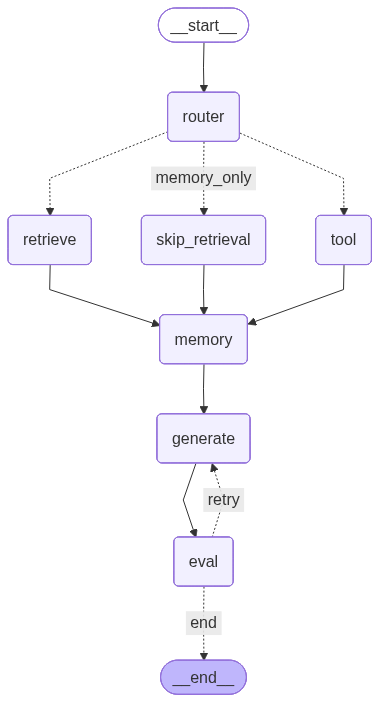

In [15]:
try:
    graph_png = app.get_graph(xray=True).draw_mermaid_png()
    from IPython.display import Image, display
    display(Image(graph_png))
except Exception as e:
    print(f'Visualization requires pygraphviz/graphviz: {e}')
    print()
    # Print Mermaid diagram text as fallback
    try:
        mermaid = app.get_graph().draw_mermaid()
        print('Mermaid diagram (paste at mermaid.live):')
        print(mermaid)
    except Exception as e2:
        print(f'Mermaid fallback also failed: {e2}')

## 13. Launch Streamlit UI

In [ ]:
# Run this in a TERMINAL (not inside the notebook cell):
# streamlit run capstone_streamlit.py

# Or launch programmatically from notebook:
import subprocess, sys
proc = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'capstone_streamlit.py',
     '--server.headless', 'true'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
print('Streamlit server starting...')
print('Open http://localhost:8501 in your browser.')
print(f'PID: {proc.pid}  (call proc.terminate() to stop)')

Streamlit server starting...
Open http://localhost:8501 in your browser.
PID: 19628  (call proc.terminate() to stop)


## 14. Capstone Architecture Summary

| Component | Implementation |
|---|---|
| **State** | `CapstoneState` (TypedDict) with 9 fields |
| **Graph** | LangGraph `StateGraph` with 7 nodes |
| **RAG** | ChromaDB + `SentenceTransformer('all-MiniLM-L6-v2')` |
| **LLM** | `llama-3.3-70b-versatile` via `ChatGroq` |
| **Memory** | `MemorySaver` + sliding window (msgs[-6:]) |
| **Self-Reflection** | `eval_node` scores faithfulness 0–1; retries if <0.7, max 2x |
| **Tools** | Drug Interaction Checker + Datetime (never raise exceptions) |
| **Routing** | `route_decision()` → retrieve / memory_only / tool |
| **Eval Gate** | `eval_decision()` → retry / end |
| **UI** | Streamlit with `@st.cache_resource` + `st.session_state` |
| **Docs** | 10 clinical policy documents, 100–300 words each |

### Node Flow
```
router → [retrieve | skip_retrieval | tool]
       → memory → generate → eval → [retry→generate | end]
```